In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys 
sys.path.append("..")
from src.preprocess.binning import term_freq_bin

In [20]:
# Load the reconstructed data and the original data
recon_data_path = "C:\\Users\\rdbra\\Documents\\honoursProject\\code_base\\Hon_proj_RDB\\GRN_work\\results\\sct_top5k_1000_7_vqvae2\\vqvae2_recon.npz"
original_data_path = "C:\\Users\\rdbra\\Documents\\honoursProject\\code_base\\Hon_proj_RDB\\GRN_work\\data\\sct_top5k_bin.npz"
recon = np.load(recon_data_path)['reconstructed_matrix']
original = np.load(original_data_path)['data']
print(f"Reconstructed data shape: {recon.shape}")
print(f"Original data shape: {original.shape}")
# Ensure the shapes match for comparison
assert recon.shape == original.shape, "Reconstructed and original data shapes do not match!"

Reconstructed data shape: (5000, 50929)
Original data shape: (5000, 50929)


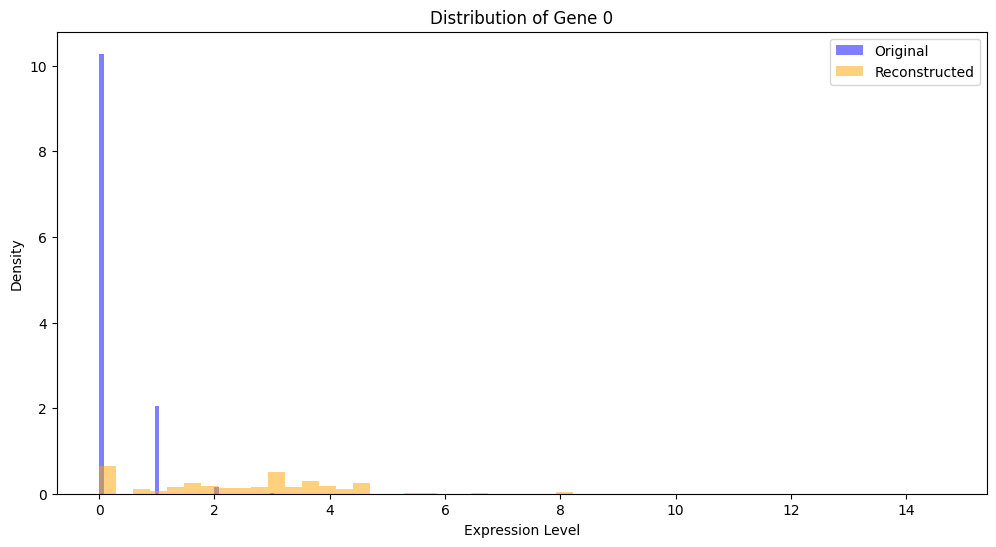

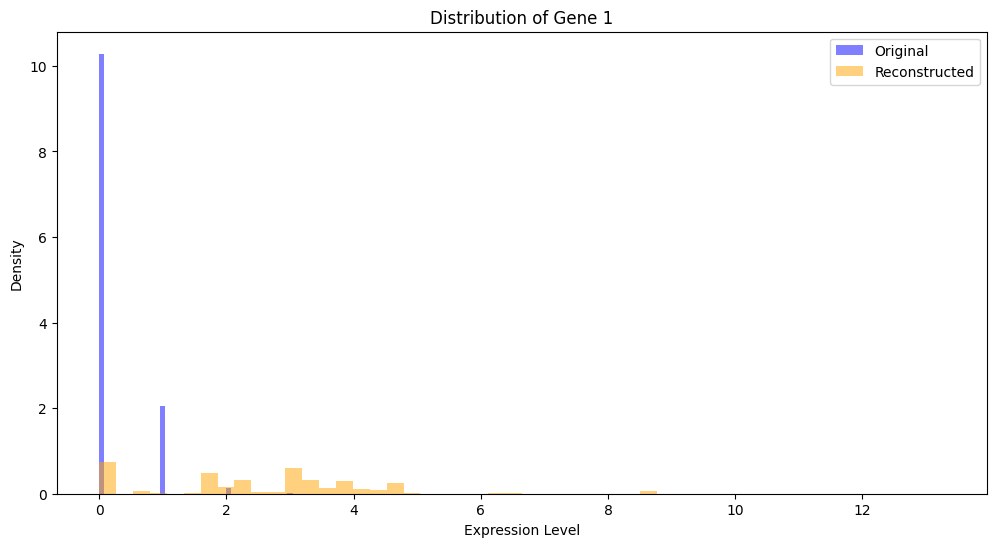

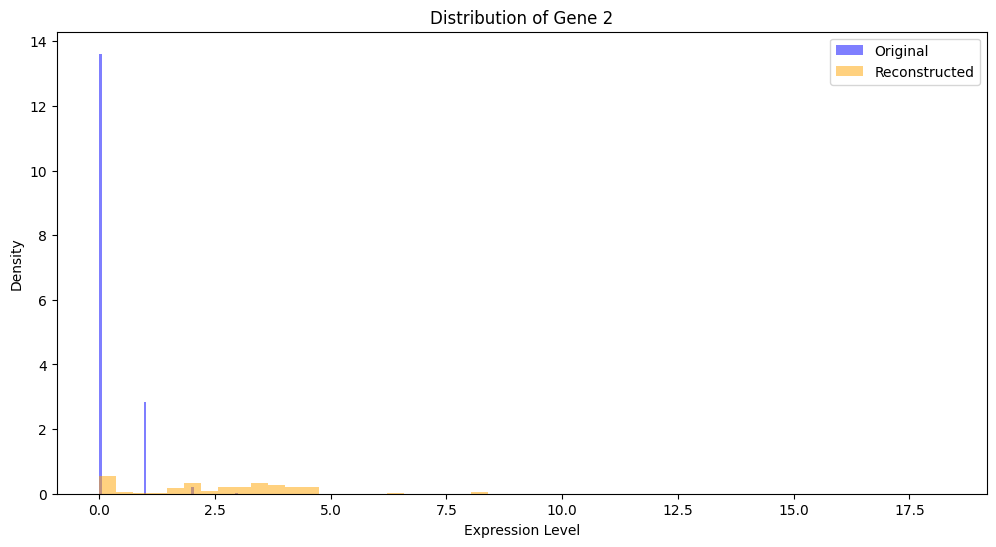

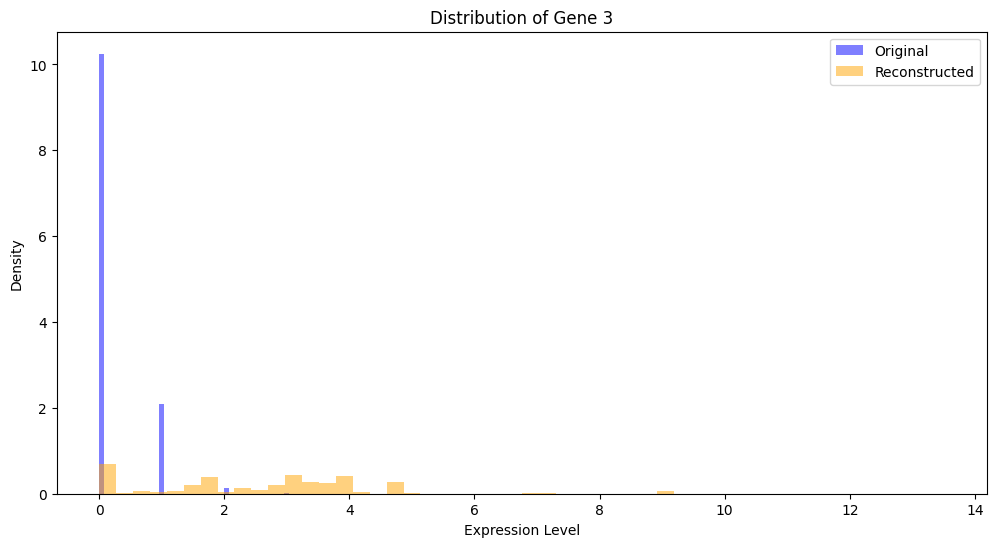

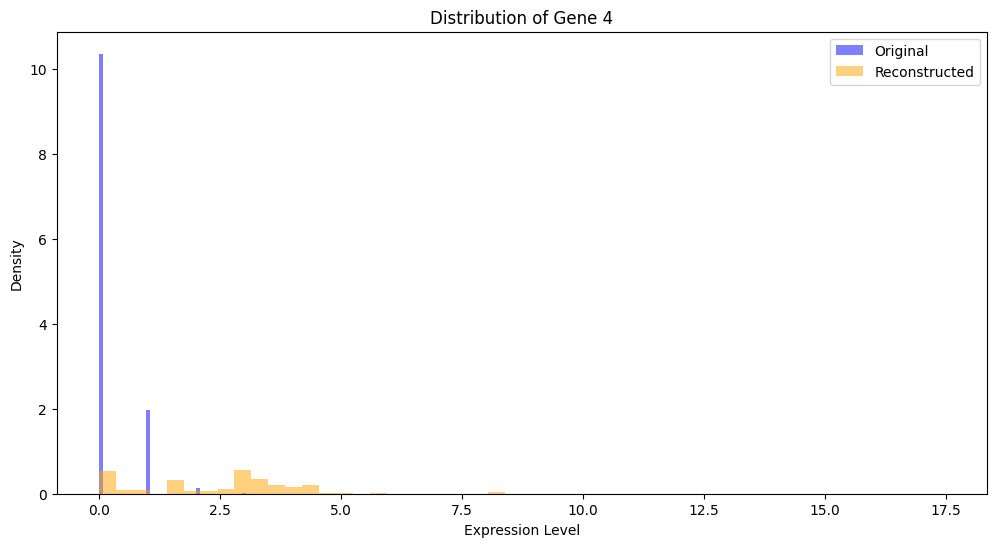

Mean Squared Error: 8.05880882522182


In [3]:
# Compare the distributions of the original and reconstructed data
def plot_distributions(original, reconstructed, gene_index):
    plt.figure(figsize=(12, 6))
    plt.hist(original[:, gene_index], bins=50, alpha=0.5, label='Original', color='blue', density=True)
    plt.hist(reconstructed[:, gene_index], bins=50, alpha=0.5, label='Reconstructed', color='orange', density=True)
    plt.title(f'Distribution of Gene {gene_index}')
    plt.xlabel('Expression Level')
    plt.ylabel('Density')
    plt.legend()
    plt.show() 

# Plot distributions for a few selected genes
for gene_idx in [0, 1, 2, 3, 4]:
    plot_distributions(original, recon, gene_idx)
# Calculate and print reconstruction error (Mean Squared Error)
mse = np.mean((original - recon) ** 2) 
print(f"Mean Squared Error: {mse}")

In [ ]:
#Print the first 5 rows of original and reconstructed data for manual inspection
print("Original Data (first 5 rows):") 
print(original[:5])
print("Reconstructed Data (first 5 rows):") 
print(recon[:5])

Original Data (first 5 rows):
[[0. 0. 0. ... 0. 0. 0.]
 [2. 2. 2. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Reconstructed Data (first 5 rows):
[[0.8086424  1.6248469  0.68298876 ... 0.37124777 2.7144713  0.        ]
 [3.6307569  3.7950106  3.547987   ... 0.         0.92502236 1.2571245 ]
 [3.6029038  3.303428   3.715075   ... 3.2488217  4.3181844  3.210184  ]
 [0.808642   1.6248472  0.68298876 ... 0.3712479  2.7144716  0.        ]
 [0.         0.         0.         ... 4.7450137  0.         0.        ]]


<class 'numpy.ndarray'> <class 'numpy.ndarray'>


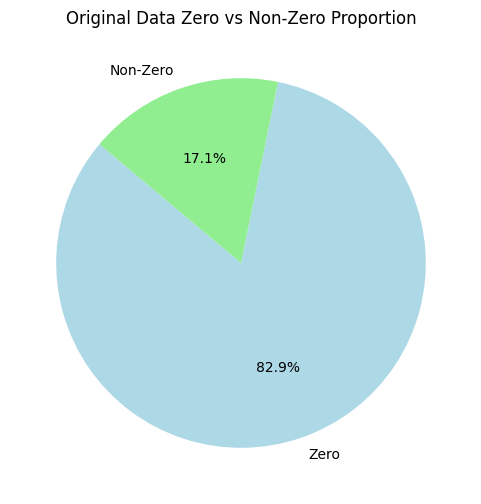

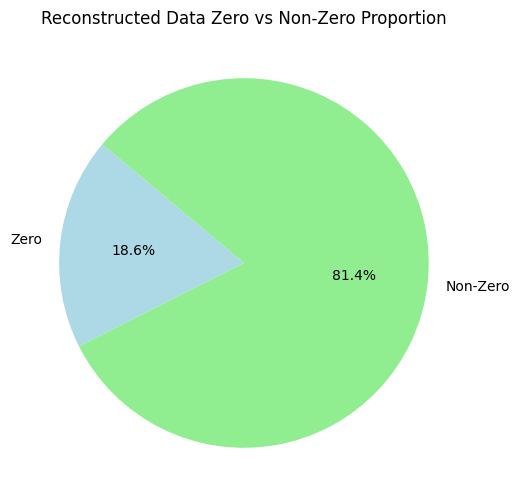

Original Data - Zero count: 211103943, Non-zero count: 43541057
Reconstructed Data - Zero count: 47270440, Non-zero count: 207374560


In [ ]:
# Create pie charts to visualize the proportion of zero vs non-zero values
def plot_zero_nonzero_proportion(data, title): 
    zero_count = np.sum(data == 0)
    nonzero_count = np.sum(data != 0)
    labels = ['Zero', 'Non-Zero']
    sizes = [zero_count, nonzero_count]
    colors = ['lightblue', 'lightgreen']
    
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
    plt.title(title)
    plt.show() 
plot_zero_nonzero_proportion(original, 'Original Data Zero vs Non-Zero Proportion')
plot_zero_nonzero_proportion(recon, 'Reconstructed Data Zero vs Non-Zero Proportion')

# Print the counts of zero and non-zero values
original_zero_count = np.sum(original == 0)
original_nonzero_count = np.sum(original != 0)
recon_zero_count = np.sum(recon == 0)
recon_nonzero_count = np.sum(recon != 0)

print(f"Original Data - Zero count: {original_zero_count}, Non-zero count: {original_nonzero_count}")
print(f"Reconstructed Data - Zero count: {recon_zero_count}, Non-zero count: {recon_nonzero_count}")

In [21]:
# Discretise the reconstructed data to nearest bin values
recon_binned = term_freq_bin(recon.copy(), num_bins=7)
# Get the bin edges used in term_freq_bin
print(bin_edges)
print("Reconstructed Data (first 5 rows):")
print(recon[:5])
print("Discretised Reconstructed Data (first 5 rows):")
print(recon_binned[:5])
print("Original Data (first 5 rows):")
print(original[:5]) 
print("Max values for each data set:")
print(f"Original Data Max: {np.max(original)}")
print(f"Reconstructed Data Max: {np.max(recon)}")
print(f"Discretised Reconstructed Data Max: {np.max(recon_binned)}")

Percentage of non-zero values: 81.44%
Bin edges: [1.5616417e-05 5.4618754e+00 1.0923735e+01 1.6385593e+01 2.1847454e+01
 2.7309315e+01 3.2771172e+01 3.8233032e+01]
[1.         1.66666667 2.33333333 3.         3.66666667 4.33333333
 5.        ]
Reconstructed Data (first 5 rows):
[[0.8086424  1.6248469  0.68298876 ... 0.37124777 2.7144713  0.        ]
 [3.6307569  3.7950106  3.547987   ... 0.         0.92502236 1.2571245 ]
 [3.6029038  3.303428   3.715075   ... 3.2488217  4.3181844  3.210184  ]
 [0.808642   1.6248472  0.68298876 ... 0.3712479  2.7144716  0.        ]
 [0.         0.         0.         ... 4.7450137  0.         0.        ]]
Discretised Reconstructed Data (first 5 rows):
[[1. 1. 1. ... 1. 1. 0.]
 [1. 1. 1. ... 0. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
Original Data (first 5 rows):
[[0. 0. 0. ... 0. 0. 0.]
 [2. 2. 2. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Max values for each data s